# RAG Agent (검색 증강 생성 에이전트)

**RAG (Retrieval-Augmented Generation)** 는 외부 지식 소스에서 정보를 검색하여 LLM의 응답을 향상시키는 기술입니다.

RAG 에이전트는 검색 도구를 사용하여 관련 문서를 찾고, 이를 컨텍스트로 활용하여 답변을 생성합니다.

**참고**: [LangChain 공식 문서 - RAG Agent](https://docs.langchain.com/oss/python/langchain/rag)

## RAG 워크플로우

1. **인덱싱 (Indexing)**: 문서를 로드, 분할, 임베딩하여 벡터 스토어에 저장
2. **검색 및 생성 (Retrieval & Generation)**: 사용자 질문에 대해 관련 문서를 검색하고 답변 생성

## RAG 패턴 이해

RAG는 두 가지 주요 접근 방식이 있습니다:

### 1 에이전트 기반 RAG (Agentic RAG)

에이전트가 필요할 때만 검색 도구를 호출합니다.
- 장점: 유연성, 필요할 때만 검색
- 단점: 여러 번의 모델 호출로 인한 지연 시간

### 2 체인 기반 RAG (Chain-based RAG)

항상 검색을 먼저 실행하고 결과를 컨텍스트로 제공합니다.
- 장점: 단일 모델 호출로 빠름
- 단점: 항상 검색하므로 유연성 낮음

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

# LangSmith 추적 (선택적)
langsmith_api_key = os.getenv("LANGCHAIN_API_KEY", "")
if langsmith_api_key:
    os.environ["LANGCHAIN_TRACING_V2"] = "true"

In [2]:
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore

# 모델 및 임베딩 초기화
model = init_chat_model("gpt-5-nano", model_provider="openai")
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# 벡터 스토어 생성
vector_store = InMemoryVectorStore(embeddings)

## 1. 인덱싱 단계

문서를 로드하고 벡터 스토어에 저장합니다.

### 1.1 문서 로드 및 분할

In [3]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 웹 문서 로드
loader = WebBaseLoader("https://botpress.com/ko/blog/llm-agents")
docs = loader.load()

print(f"로드된 문서 수: {len(docs)}")
print(f"문서 길이: {len(docs[0].page_content)} 문자")

# 텍스트 분할
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    add_start_index=True
)

all_splits = text_splitter.split_documents(docs)
print(f"\n분할된 청크 수: {len(all_splits)}")

USER_AGENT environment variable not set, consider setting it to identify your requests.


로드된 문서 수: 1
문서 길이: 9530 문자

분할된 청크 수: 17


### 1.2 벡터 스토어에 저장

In [4]:
# 문서를 벡터 스토어에 추가
document_ids = vector_store.add_documents(documents=all_splits)
print(f"저장된 문서 ID 수: {len(document_ids)}")

저장된 문서 ID 수: 17


### 2. 에이전트 기반 RAG (Agentic RAG)

### 2.1 검색 도구 생성

In [5]:
from langchain.tools import tool

@tool(response_format="content_and_artifact")
def retrieve_context(query: str):
    """질문에 답하기 위해 관련 정보를 검색합니다.
    
    이 도구는 벡터 스토어에서 질문과 관련된 문서를 검색합니다.
    검색된 문서는 답변 생성에 사용됩니다.
    
    Args:
        query: 검색할 질문 또는 키워드
    """
    # 벡터 스토어에서 유사한 문서 검색
    retrieved_docs = vector_store.similarity_search(query, k=2)
    
    # 검색된 문서를 문자열로 직렬화
    serialized = "\n\n".join(
        f"출처: {doc.metadata.get('source', 'N/A')}\n내용: {doc.page_content}"
        for doc in retrieved_docs
    )
    
    # 문자열과 문서 객체를 함께 반환
    return serialized, retrieved_docs

# 도구 테스트
test_result = retrieve_context.invoke("LLM 에이전트의 구성 요소")
print(test_result[0][:300] + "...")

출...


### 2.2 RAG 에이전트 생성

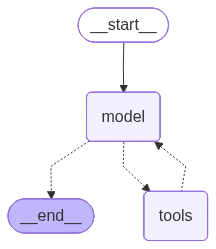

In [7]:
from langchain.agents import create_agent

# 시스템 프롬프트 설정
system_prompt = (
    "당신은 블로그 게시글에서 관련 문맥(context)을 검색하는 도구에 접근할 수 있습니다. "
    "사용자의 질문에 답하기 위해 먼저 retrieve_context 도구를 사용하여 관련 정보를 검색한 후, "
    "검색된 정보를 바탕으로 정확하고 유용한 답변을 제공하세요."
)

# 에이전트 생성
agent = create_agent(
    model,
    tools=[retrieve_context],
    system_prompt=system_prompt
)

agent

### 2.3 에이전트 실행

In [8]:
# 질문에 대한 답변 생성
query = "LLM 에이전트 프레임워크를 구성하는 핵심 구성 요소는 무엇인가요?"

print(f"질문: {query}\n")
print("=" * 80)

# 스트리밍 방식으로 실행
for event in agent.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",
):
    event["messages"][-1].pretty_print()

질문: LLM 에이전트 프레임워크를 구성하는 핵심 구성 요소는 무엇인가요?

================================ Human Message =================================

LLM 에이전트 프레임워크를 구성하는 핵심 구성 요소는 무엇인가요?
================================== Ai Message ==================================
Tool Calls:
  retrieve_context (call_ogRDygrQnApyrL0ffIYvTxiv)
 Call ID: call_ogRDygrQnApyrL0ffIYvTxiv
  Args:
    query: LLM 에이전트 프레임워크 핵심 구성 요소
================================= Tool Message =================================
Name: retrieve_context

출처: https://botpress.com/ko/blog/llm-agents
내용: 최신 LLM으로 구동되는 맞춤형 자율 에이전트 구축


지금 시작하기









LLM 에이전트는 어떻게 작동하나요?LLM 에이전트는 LLM의 강력함에 검색, 추론, 메모리, 도구 활용을 결합해 자율적으로 작업을 완수합니다. 각 구성 요소의 역할을 살펴보겠습니다.

검색
대부분의 에이전트는 검색 증강 생성(RAG)을 사용해 실시간 데이터에 접근합니다. 예를 들어, 법률 에이전트는 규제 변경 사항을, 이커머스 에이전트는 상품 재고를 확인할 수 있습니다.



추론
LLM 에이전트 개발자는 고급 프롬프트 기법을 활용해 에이전트의 의사결정 방식을 안내할 수 있습니다.



메모리
LLM 에이전트는 단기 메모리(최근 대화 이력), 장기 메모리(구조화된 정보 저장), 작업별 기억 기능을 갖추고 있어, 상황에 맞게 적응하고 개인화된 결정을 내릴 수 있습니다.



도구 사용
대화뿐 아니라, LLM 에이전트는 거의

### 2.4 여러 질문 테스트

In [9]:
queries = [
    "에이전트의 주요 특징은 무엇인가요?",
    "프롬프트 엔지니어링이 중요한 이유는 무엇인가요?"
]

for query in queries:
    print(f"\n{'='*80}")
    print(f"질문: {query}")
    print("="*80)
    
    result = agent.invoke({
        "messages": [{"role": "user", "content": query}]
    })
    
    print("\n답변:")
    result["messages"][-1].pretty_print()


질문: 에이전트의 주요 특징은 무엇인가요?

답변:
================================== Ai Message ==================================

에이전트의 주요 특징은 다음과 같습니다.

- 자율성(Autonomy): LLM을 기반으로 스스로 의사결정하고 작업을 수행합니다.
- 검색 능력(RAG): 실시간 데이터에 접근하기 위해 검색 증강 생성(RAG)을 사용합니다. 예를 들어 규제 변경이나 재고 상태를 확인하는 식으로 맥락을 보강합니다.
- 추론 능력: 고급 프롬프트 기법을 활용해 의사결정 방식과 행동 계획을 설계하고 실행합니다.
- 메모리 관리: 
  - 단기 메모리: 최근 대화 이력으로 현재 상황을 파악합니다.
  - 장기 메모리: 구조화된 정보 저장으로 맥락을 축적하고 개인화된 결정을 내립니다.
  - 작업별 기억: 특정 작업의 정보를 지속적으로 활용합니다.
- 도구 활용/외부 시스템 연동: 다양한 외부 시스템과 연동해 데이터를 가져오고 작업을 수행합니다. 예를 들어 파이썬 코드 실행으로 디버깅하거나 CRM의 주문 이력을 확인하는 등의 활용이 가능합니다.

요약하면, 자동화된 의사결정과 실행을 위해 검색, 추론, 맥락(메모리) 관리, 그리고 외부 도구 연동의 네 가지 핵심 요소가 결합된 형태입니다.

질문: 프롬프트 엔지니어링이 중요한 이유는 무엇인가요?

답변:
================================== Ai Message ==================================

프롬프트 엔지니어링은 LLM 기반 시스템의 성능과 비용, 활용 가능성을 좌우하는 핵심 기술입니다. 아래처럼 왜 중요한지 요약해 드립니다.

주요 이유

- 비용과 유지보수의 균형: 파인튜닝은 비용이 크고 유지 관리가 필요합니다. 반면 프롬프트 엔지니어링은 모델 파라미터를 바꾸지 않고도 원하는 동작을 유도할 수 있어 초기 비용이 낮고 빠르게 수정·실험이 가능합니다. 파인튜닝은 정적 지식에 강한 챗

### 3. 체인 기반 RAG (Chain-based RAG)

In [11]:
# 체인 기반 RAG 예제
from langchain_core.messages import HumanMessage

def chain_based_rag(query: str):
    """체인 기반 RAG: 항상 검색 후 답변 생성"""
    # 1. 검색
    retrieved_docs = vector_store.similarity_search(query, k=2)
    context = "\n\n".join(doc.page_content for doc in retrieved_docs)
    
    # 2. 컨텍스트와 함께 답변 생성
    messages = [
        HumanMessage(content=f"""다음 컨텍스트를 참고하여 질문에 답변하세요:

컨텍스트:
{context}

질문: {query}

답변:""")
    ]
    
    response = model.invoke(messages)
    return response.content

# 체인 기반 RAG 테스트
query = "에이전트의 주요 특징은?"
print(f"질문: {query}\n")
answer = chain_based_rag(query)
print(f"답변: {answer}")

질문: 에이전트의 주요 특징은?

답변: 에이전트의 주요 특징은 다음 네 가지입니다.

- 검색 기능: 실시간 데이터에 접근하기 위해 검색 증강(RAG)을 사용합니다(예: 규제 변경 확인, 재고 조회 등).
- 추론 능력: 고급 프롬프트 기법으로 의사결정 과정을 가이드하고 합리적인 판단을 내립니다.
- 메모리: 단기 대화 이력과 장기 메모리(구조화된 정보)로 맥락을 유지하고 개인화된 반응을 제공합니다.
- 도구 활용: 외부 시스템(API, 데이터베이스, 코딩 실행 등)과 연동해 데이터를 조회하고 작업을 실제로 수행합니다.

이 네 가지를 결합해 자율적으로 다단계 워크플로우를 처리합니다.


## 4. 실전 예제: PDF 문서 기반 RAG

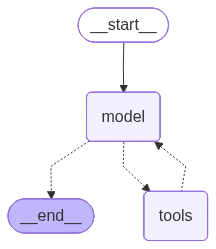

In [13]:
from langchain_community.document_loaders import PyPDFLoader

# PDF 문서 로드 (이미 110_Semantic_Search.py에서 인덱싱했다고 가정)
# 실제로는 별도의 인덱싱 프로세스로 실행

# PDF 기반 검색 도구
@tool(response_format="content_and_artifact")
def retrieve_pdf_context(query: str):
    """PDF 문서에서 관련 정보를 검색합니다."""
    # 실제로는 별도로 인덱싱된 PDF 벡터 스토어 사용
    # 여기서는 예제로 기존 벡터 스토어 사용
    retrieved_docs = vector_store.similarity_search(query, k=3)
    
    serialized = "\n\n".join(
        f"페이지: {doc.metadata.get('page', 'N/A')}\n내용: {doc.page_content}"
        for doc in retrieved_docs
    )
    
    return serialized, retrieved_docs

# PDF RAG 에이전트
pdf_agent = create_agent(
    model,
    tools=[retrieve_pdf_context],
    system_prompt="당신은 PDF 문서를 검색하여 질문에 답변하는 AI 어시스턴트입니다."
)

pdf_agent

## 주요 포인트 정리

1. **인덱싱**: 문서 로드 → 분할 → 임베딩 → 벡터 스토어 저장
2. **검색 도구**: 벡터 스토어를 래핑한 도구 생성
3. **에이전트 통합**: 검색 도구를 에이전트에 추가
4. **에이전트 기반 vs 체인 기반**: 필요에 따라 선택

**다음 단계**: 
- [230_Custom_RAG_LangGraph.py](230_Custom_RAG_LangGraph.py)에서 LangGraph로 더 세밀한 제어 구현
- [streamlit-llm_LangChain/120_RAG_Chatbot.py](streamlit-llm_LangChain/120_RAG_Chatbot.py)에서 웹 UI 구현